### Goals:
#### 1. EDA (Exploratory Data Analysis):
 - View delivery time distribution (in a larger view).
 - Check what the delivery time depends on: weather, traffic, area, vehicle, Agent_Age, Agent_Rating.
 - Find the most common order categories (Category) and areas (Area).

 #### 2. Geoanalysis
  - Use Store_Latitude/Longitude -> Calculate the distance
  - Check: does delivery time increase with the distance?

  #### 3. Features Engineering
  Create new features:
    - DayOfWeek, Hour from Order_Date and Order_Time
    - The differences between Pickup_Time and Order_Time
    - Categorize the age of couriers (young, middle, old)

#### 4. Influence of conditions
Build graphs:
- Influence of weather
- Influence of traffic
- Influence of Vehicle

#### 5. ML-model (Regression)

<b>Task</b>: predict Delivery_Time.

<b>Use</b> features: distance, weather, traffic, category, type of transport, agent rating, etc.

<b>Compare</b> models: Linear Regression, Random Forest, Gradient Boosting.

#### 6. ML model (Classification)
Divide delivery into classes:
- Fast (≤120 min), Medium (121–150), Slow (>150).
- Train the classifier (Logistic Regression, Random Forest, XGBoost).

#### 7. Business Insights
Find the top 3 slowest areas and product categories.

<b>Recommendations: </b> where more couriers are needed, what weather conditions have the greatest impact.

# 1. EDA

In [116]:
import pandas as pd
import numpy as np

In [117]:
df = pd.read_csv("amazon_delivery.csv")
df.head(5)

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


In [118]:
print(f"DataFrame has {df.shape[0]} rows and {df.shape[1]} columns")

DataFrame has 43739 rows and 16 columns


In [119]:
descriptions = {
    "Order_ID": "Unique identifier for each order",
    "Agent_Age": "Age of the delivery agent",
    "Agent_Rating": "Rating of the delivery agent",
    "Store_Latitude": "Latitude of the store location",
    "Store_Longitude": "Longitude of the store location",
    "Drop_Latitude": "Latitude of the drop (customer) location",
    "Drop_Longitude": "Longitude of the drop (customer) location",
    "Order_Date": "Date when the order was placed",
    "Order_Time": "Time when the order was placed",
    "Pickup_Time": "Time when the order was picked up by the agent",
    "Weather": "Weather condition during the delivery",
    "Traffic": "Traffic condition during the delivery",
    "Vehicle": "Type of vehicle used for delivery",
    "Area": "Type of area (Urban, Metropolitian, etc.)",
    "Delivery_Time": "Time taken for delivery (in minutes)",
    "Category": "Product category of the order"
}





In [120]:
columns_info = pd.DataFrame({
    "Column": df.columns,
    "DataType": df.dtypes.values,
    "MissingValues": df.isnull().sum().values,
    "UniqueValues": df.nunique().values,
    "Description": [descriptions[col] for col in df.columns]
})

columns_info

,Column,DataType,MissingValues,UniqueValues,Description
0,Order_ID,object,0,43739,Unique identifier for each order
1,Agent_Age,int64,0,22,Age of the delivery agent
2,Agent_Rating,float64,54,28,Rating of the delivery agent
3,Store_Latitude,float64,0,521,Latitude of the store location
4,Store_Longitude,float64,0,415,Longitude of the store location
5,Drop_Latitude,float64,0,4367,Latitude of the drop (customer) location
6,Drop_Longitude,float64,0,4367,Longitude of the drop (customer) location
7,Order_Date,object,0,44,Date when the order was placed
8,Order_Time,object,0,177,Time when the order was placed
9,Pickup_Time,object,0,193,Time when the order was picked up by the agent


In [121]:
print("Unique values")

for col in df.columns:
    if df[col].nunique() < 20:
        print(f"{col} : {df[col].unique()}")

Unique values
Weather : ['Sunny' 'Stormy' 'Sandstorms' 'Cloudy' 'Fog' 'Windy' nan]
Traffic : ['High ' 'Jam ' 'Low ' 'Medium ' 'NaN ']
Vehicle : ['motorcycle ' 'scooter ' 'van' 'bicycle ']
Area : ['Urban ' 'Metropolitian ' 'Semi-Urban ' 'Other']
Category : ['Clothing' 'Electronics' 'Sports' 'Cosmetics' 'Toys' 'Snacks' 'Shoes'
 'Apparel' 'Jewelry' 'Outdoors' 'Grocery' 'Books' 'Kitchen' 'Home'
 'Pet Supplies' 'Skincare']


In [122]:
df = df.dropna(subset=['Weather'])
df["Agent_Rating"] = df["Agent_Rating"].fillna(df["Agent_Rating"].median())

print(df.isnull().sum())
print("New shape:", df.shape)

Order_ID           0
Agent_Age          0
Agent_Rating       0
Store_Latitude     0
Store_Longitude    0
Drop_Latitude      0
Drop_Longitude     0
Order_Date         0
Order_Time         0
Pickup_Time        0
Weather            0
Traffic            0
Vehicle            0
Area               0
Delivery_Time      0
Category           0
dtype: int64
New shape: (43648, 16)


##### 1.1 Descriptive stats for Delivery_Time


In [123]:
delivery_stats = df["Delivery_Time"].describe(
    percentiles=[0.10, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
)
print("Delivery_Time distribution:\n", delivery_stats)

print("\nUnique values:", df["Delivery_Time"].nunique())
print("Min:", df["Delivery_Time"].min(), "Max:", df["Delivery_Time"].max())

Delivery_Time distribution:
 count    43648.000000
mean       124.914475
std         51.933163
min         10.000000
10%         60.000000
25%         90.000000
50%        125.000000
75%        160.000000
90%        195.000000
95%        215.000000
99%        245.000000
max        270.000000
Name: Delivery_Time, dtype: float64

Unique values: 89
Min: 10 Max: 270


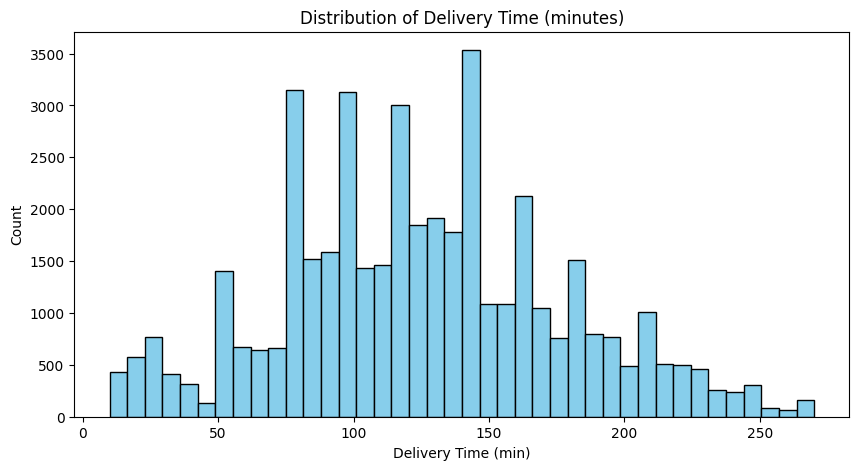

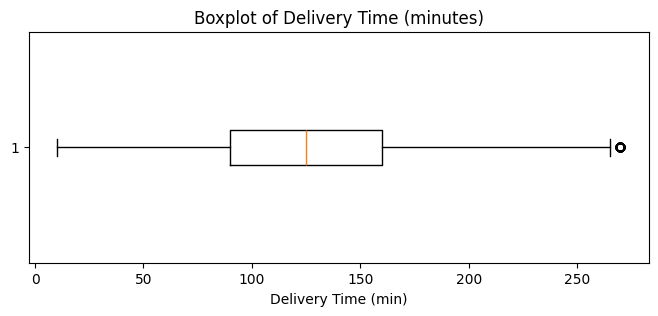

In [124]:
import matplotlib.pyplot as plt

# Histogram
plt.figure(figsize=(10,5))
plt.hist(df["Delivery_Time"], bins=40, color="skyblue", edgecolor="black")
plt.title("Distribution of Delivery Time (minutes)")
plt.xlabel("Delivery Time (min)")
plt.ylabel("Count")
plt.show()

# Boxplot
plt.figure(figsize=(8,3))
plt.boxplot(df["Delivery_Time"], vert=False)
plt.title("Boxplot of Delivery Time (minutes)")
plt.xlabel("Delivery Time (min)")
plt.show()


### 🔎 Insights from Delivery Time Distribution

- **Median delivery time ≈ 125 minutes** (~2 hours).  
- **50% of deliveries (IQR)** are completed between **90 and 160 minutes**.  
- **Most common delivery times** cluster around 90, 120, and 150 minutes – possible standard service levels.  
- **Fast deliveries (<30 min)** exist but are rare.  
- **Long deliveries (>200 min)** appear as outliers, up to 270 minutes.  

 **Conclusion:**  
The majority of orders are delivered within 2 hours, which is typical for local courier services (scooter/motorcycle/van).  
Outliers on the right tail (200+ minutes) highlight operational delays that should be investigated and optimized.

##### 1.2 Delivery Time by Categories (Weather, Traffic, Area, Vehicle)

In [125]:
for col in ["Weather", "Traffic", "Area", "Vehicle"]:
    g = (
        df.groupby(col)["Delivery_Time"]
          .agg(Count="count", Mean="mean", Median="median", Std="std")
          .round(2)
          .sort_values("Mean")
    )
    print(f"\nDelivery_Time by {col}:\n", g)



Delivery_Time by Weather:
             Count    Mean  Median    Std
Weather                                 
Sunny        7078  103.66   100.0  45.44
Stormy       7374  123.21   125.0  47.80
Sandstorms   7245  123.24   125.0  48.31
Windy        7223  123.66   125.0  48.52
Fog          7440  136.57   135.0  57.23
Cloudy       7288  138.29   140.0  55.47

Delivery_Time by Traffic:
          Count    Mean  Median    Std
Traffic                              
Low      14999  101.35   100.0  38.80
Medium   10628  126.84   130.0  48.71
High      4296  129.42   135.0  48.27
Jam      13725  147.76   150.0  56.81

Delivery_Time by Area:
                 Count    Mean  Median    Std
Area                                        
Other            1136  104.50   100.0  45.98
Urban            9726  109.44   105.0  48.22
Metropolitian   32634  129.71   130.0  51.59
Semi-Urban        152  238.55   245.0  47.03

Delivery_Time by Vehicle:
              Count    Mean  Median    Std
Vehicle                

### 🔎 Insights: Factors Affecting Delivery Time

**Weather**
- Deliveries are fastest in **Sunny** conditions (median ~100 min).
- **Cloudy and Foggy** weather significantly increases delivery time (median ~140–150 min).
- Bad weather → wider spread of times (more uncertainty).

**Traffic**
- Clear pattern: **more traffic → slower delivery**.
- **Low traffic** → median ~100 min.
- **Jam** → median ~150+ min, many long delays (outliers).

**Area**
- **Urban & Metropolitan** → typical delivery ~100–130 min.
- **Semi-Urban** → extremely long times (median ~240 min) → hardest conditions.
- **Other** → closer to Urban, ~100 min.

**Vehicle**
- **Scooter & Van** deliver slightly faster (median ~110–120 min).
- **Motorcycle** shows a bit longer times (~130 min).
- Spread is wide for all vehicles → external factors (traffic/weather) dominate more than vehicle type.

📌 **Conclusion:**  
Weather, traffic, and delivery area strongly affect delivery time.  
Semi-Urban areas, traffic jams, and bad weather (fog, cloudy) create the biggest delays.  
Vehicle type has smaller impact compared to these external factors.


##### 1.3 Agent_Age & Agent_Rating

In [127]:
# Correlations
print("\nCorrelation(Agent_Age, Delivery_Time):",
      df[["Agent_Age", "Delivery_Time"]].corr().iloc[0, 1].round(3))

print("Correlation(Agent_Rating, Delivery_Time):",
      df[["Agent_Rating", "Delivery_Time"]].corr().iloc[0, 1].round(3))

# Binning for better view
age_bins = pd.cut(df["Agent_Age"], bins=[0,22,26,30,35,50],
                  labels=["<=22", "23-26", "27-30", "31-35", "36+"])
print("\nDelivery_Time by Age groups:\n",
      df.groupby(age_bins)["Delivery_Time"].agg(Count="count", Mean="mean").round(2))

rating_bins = pd.cut(df["Agent_Rating"], bins=[0,3.5,4.0,4.5,5.1],
                     labels=["<=3.5","3.6-4.0","4.1-4.5","4.6-5.0"])
print("\nDelivery_Time by Rating groups:\n",
      df.groupby(rating_bins)["Delivery_Time"].agg(Count="count", Mean="mean").round(2))



Correlation(Agent_Age, Delivery_Time): 0.259
Correlation(Agent_Rating, Delivery_Time): -0.308

Delivery_Time by Age groups:
            Count    Mean
Agent_Age               
<=22        6485  108.96
23-26       8630  109.40
27-30       8746  116.65
31-35      10937  141.06
36+         8850  139.95

Delivery_Time by Rating groups:
               Count    Mean
Agent_Rating               
<=3.5           472  174.70
3.6-4.0        1934  168.53
4.1-4.5        8921  145.59
4.6-5.0       32321  115.87


/var/folders/kx/sc3d8b2x5b5gtm156t69kthr0000gn/T/ipykernel_5811/591672318.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(age_bins)["Delivery_Time"].agg(Count="count", Mean="mean").round(2))
/var/folders/kx/sc3d8b2x5b5gtm156t69kthr0000gn/T/ipykernel_5811/591672318.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(rating_bins)["Delivery_Time"].agg(Count="count", Mean="mean").round(2))


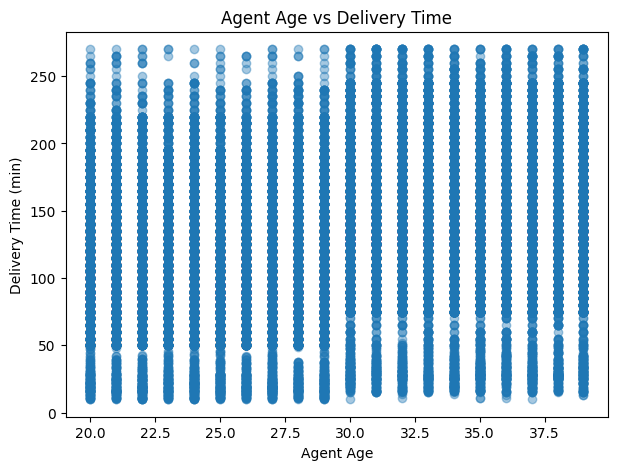

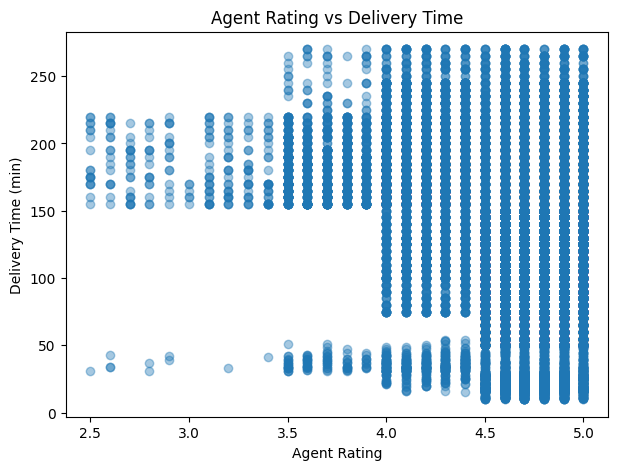

In [128]:
# Scatter Age vs Delivery Time
plt.figure(figsize=(7,5))
plt.scatter(df["Agent_Age"], df["Delivery_Time"], alpha=0.4)
plt.title("Agent Age vs Delivery Time")
plt.xlabel("Agent Age")
plt.ylabel("Delivery Time (min)")
plt.show()

# Scatter Rating vs Delivery Time
plt.figure(figsize=(7,5))
plt.scatter(df["Agent_Rating"], df["Delivery_Time"], alpha=0.4)
plt.title("Agent Rating vs Delivery Time")
plt.xlabel("Agent Rating")
plt.ylabel("Delivery Time (min)")
plt.show()


### 🔎 Insights: Agent Age & Rating

**Agent Age**
- Deliveries are fairly consistent across ages 20–39.  
- Small positive correlation (r ≈ 0.25): older agents may take slightly longer, but the effect is weak.  
- Age is not a major driver of delivery performance.

**Agent Rating**
- Negative correlation (r ≈ –0.29): higher-rated agents tend to deliver faster.  
- Agents with lower ratings (<3.5) show more variability and longer times.  
- High ratings (4.5–5.0) are associated with more stable and shorter delivery times.

📌 **Conclusion:**  
Agent **rating** influences delivery time more than age.  
Performance improvements should focus on **training and monitoring agent quality**, rather than age.


##### 1.4.Most Common Categories & Areas

In [129]:
# Categories
cat_counts = (
    df["Category"].value_counts()
      .to_frame("Count")
      .assign(Percent=lambda x: (x["Count"]/len(df)*100).round(2))
)
print("\nTop product categories:\n", cat_counts.head(10))

# Areas
area_counts = (
    df["Area"].value_counts()
      .to_frame("Count")
      .assign(Percent=lambda x: (x["Count"]/len(df)*100).round(2))
)
print("\nAreas distribution:\n", area_counts)



Top product categories:
              Count  Percent
Category                   
Electronics   2843     6.51
Books         2817     6.45
Jewelry       2796     6.41
Toys          2773     6.35
Snacks        2767     6.34
Skincare      2766     6.34
Outdoors      2741     6.28
Apparel       2722     6.24
Sports        2711     6.21
Grocery       2688     6.16

Areas distribution:
                 Count  Percent
Area                          
Metropolitian   32634    74.77
Urban            9726    22.28
Other            1136     2.60
Semi-Urban        152     0.35


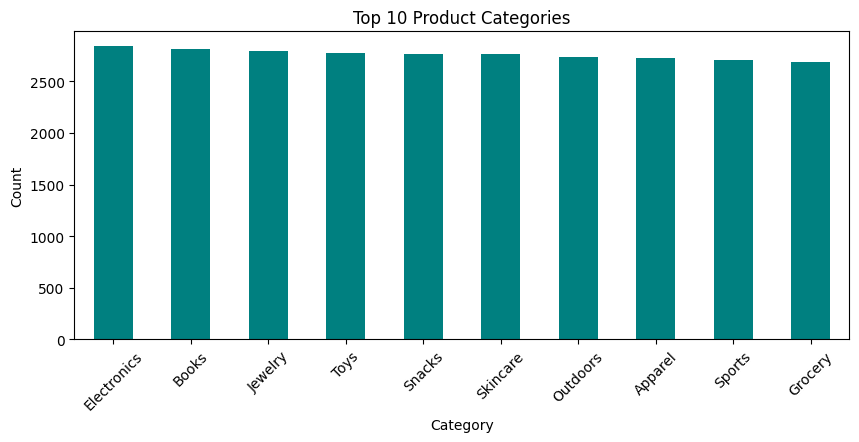

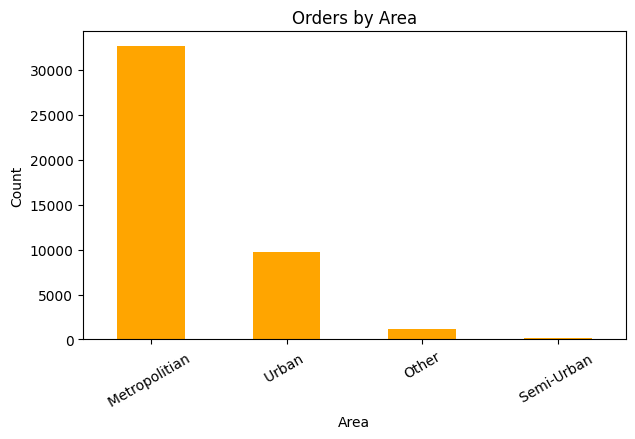

In [130]:
# Top categories
df["Category"].value_counts().head(10).plot(kind="bar", figsize=(10,4), color="teal")
plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Areas
df["Area"].value_counts().plot(kind="bar", figsize=(7,4), color="orange")
plt.title("Orders by Area")
plt.xlabel("Area")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()


### 🔎 Insights: Product Categories & Areas

**Product Categories**
- Top-10 categories (Electronics, Books, Jewelry, Toys, Snacks, etc.) have **almost the same order counts** (~2700–2800 each).  
- This suggests that demand is evenly distributed across product categories in this dataset.  

**Areas**
- Most orders come from **Metropolitan areas (~33k)**, followed by **Urban (~10k)**.  
- Very few orders in **Other** (~1k) and **Semi-Urban (~150)** areas.  
- This is expected since **population density is much higher in cities**, leading to more deliveries.  

📌 **Conclusion:**  
The dataset represents mainly **urban & metropolitan deliveries** across diverse product categories.  
Category demand is balanced, while geographic demand is highly concentrated in cities.


## 📊 EDA Summary

### Delivery Time Distribution
- Median delivery time ≈ **125 min (~2 hours)**.  
- 50% of deliveries (IQR) fall between **90–160 min**.  
- Minimum = **10 min**, maximum = **270 min**.  
- Outliers exist: very fast deliveries (<30 min) and very delayed (>200 min).  

### Effect of Weather
- **Sunny** deliveries are fastest (mean ≈ 104 min).  
- **Foggy & Cloudy** weather increases delivery times (mean ≈ 137–138 min).  
- Bad weather adds more variability and uncertainty.  

### Effect of Traffic
- Clear relationship: **more traffic → slower delivery**.  
- **Low traffic** mean ≈ 101 min, while **Jam** mean ≈ 148 min.  
- Traffic jams create the longest delays.  

### Effect of Area
- **Urban**: mean ≈ 109 min.  
- **Metropolitan**: slower, mean ≈ 130 min.  
- **Semi-Urban**: extremely slow, mean ≈ 239 min.  
- Geographic area strongly affects delivery performance.  

### Effect of Vehicle
- **Scooters & Vans**: ~116 min.  
- **Motorcycles**: slower, ~131 min.  
- Vehicle type has moderate impact compared to weather/traffic.  

### Agent Age
- Younger agents (≤30 years) deliver faster (~109–117 min).  
- Older agents (31–35, 36+) take longer (~140 min).  
- Weak positive correlation with delivery time (r ≈ 0.26).  

### Agent Rating
- Clear negative correlation (r ≈ –0.31).  
- **High-rated agents (4.6–5.0)**: mean ≈ 116 min.  
- **Low-rated agents (<3.5)**: much slower (mean ≈ 175 min).  
- Rating is more predictive than age.  

### Product Categories
- Top 10 categories (Electronics, Books, Jewelry, Toys, etc.) all have ~2700 orders each.  
- Demand is evenly distributed across product categories.  

### Areas Distribution
- Deliveries are heavily concentrated in **Metropolitan areas (75%)**, then **Urban (22%)**.  
- Very few in **Other (2.6%)** and **Semi-Urban (0.35%)**.  
- This matches population density: more people → more deliveries.  

---

📌 **Overall Conclusion:**  
- Typical delivery time = **~2 hours**.  
- **Weather, traffic, and area** are the strongest external drivers of delays.  
- **Agent rating** matters more than age: better-rated agents deliver faster.  
- Orders come mainly from **Metropolitan/Urban areas**, and product demand is balanced.  


# 2. Geoanalysis

In [131]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df["Distance_km"] = haversine(
    df["Store_Latitude"], df["Store_Longitude"],
    df["Drop_Latitude"], df["Drop_Longitude"]
)

print("All distances (km):\n", df["Distance_km"].describe())

df_near = df[df["Distance_km"] <= 50]

print("\nFiltered distances (<=50 km):\n", df_near["Distance_km"].describe())

corr = df_near[["Distance_km","Delivery_Time"]].corr().iloc[0,1]
print("\nCorrelation (<=50 km):", round(corr,3))


All distances (km):
 count    43648.000000
mean        27.255432
std        303.815765
min          1.465067
25%          4.663432
50%          9.220419
75%         13.682165
max       6884.726399
Name: Distance_km, dtype: float64

Filtered distances (<=50 km):
 count    43492.000000
mean         9.733464
std          5.604463
min          1.465067
25%          4.663412
50%          9.220178
75%         13.681416
max         20.969489
Name: Distance_km, dtype: float64

Correlation (<=50 km): 0.277


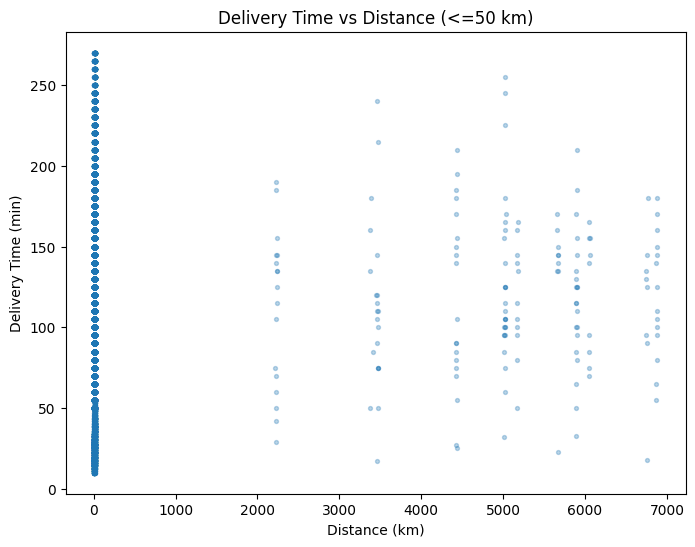

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df["Distance_km"], df["Delivery_Time"], alpha=0.3, s=8)
plt.title("Delivery Time vs Distance (<=50 km)")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.show()


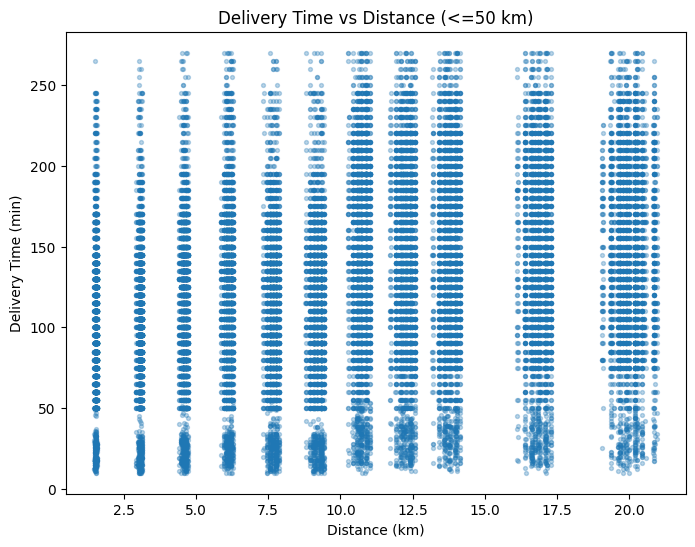

In [133]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df_near["Distance_km"], df_near["Delivery_Time"], alpha=0.3, s=8)
plt.title("Delivery Time vs Distance (<=50 km)")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.show()


In [134]:
import folium

sample = df.sample(500, random_state=42)

m = folium.Map(location=[sample["Store_Latitude"].mean(),
                         sample["Store_Longitude"].mean()],
               zoom_start=10)

for _, row in sample.iterrows():
    folium.Marker(
        location=[row["Store_Latitude"], row["Store_Longitude"]],
        popup="Store",
        icon=folium.Icon(color="blue", icon="shopping-cart")
    ).add_to(m)

    folium.Marker(
        location=[row["Drop_Latitude"], row["Drop_Longitude"]],
        popup="Drop",
        icon=folium.Icon(color="green", icon="user")
    ).add_to(m)

    folium.PolyLine(
        locations=[
            [row["Store_Latitude"], row["Store_Longitude"]],
            [row["Drop_Latitude"], row["Drop_Longitude"]]
        ],
        color="red", weight=1, opacity=0.6
    ).add_to(m)

m.save("map.html")

m


## 🔎 Insights: Geoanalysis

**Delivery distances**
- Most deliveries are **short range (<20 km)**.  
- Median distance is small (a few km), confirming **local city deliveries**.  
- A few outliers exist (stores/drops mapped far away, even in the ocean) → these are likely **data errors**.

**Delivery time vs distance**
- Positive correlation: longer distance → generally longer delivery time.  
- However, the correlation is **weak** (not strictly linear).  
- Many short-distance deliveries still take a long time → delays due to traffic, weather, or logistics.  
- Most deliveries are **1–2 hours**, regardless of distance up to ~20 km.

**Map analysis**
- Deliveries are concentrated in **India (urban/metropolitan regions)**.  
- A few anomalous points appear in Africa or the ocean → should be filtered out as invalid coordinates.

📌 **Conclusion:**  
Distance does affect delivery time, but it is **not the main driver**.  
External conditions (traffic, weather, area type) have stronger impact on delays.  
The dataset represents **urban last-mile deliveries**, typically within **10–20 km**.


# 3. Feature Engineering

In [139]:
df1 = df.copy()

In [142]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["Order_Time"] = pd.to_datetime(df["Order_Time"], format="%H:%M:%S", errors="coerce")
df["Pickup_Time"] = pd.to_datetime(df["Pickup_Time"], format="%H:%M:%S", errors="coerce")

In [148]:
df["Order_DT"] = df["Order_Date"].dt.date.astype(str) + " " + df["Order_Time"].dt.strftime("%H:%M:%S")
df["Pickup_DT"] = df["Order_Date"].dt.date.astype(str) + " " + df["Pickup_Time"].dt.strftime("%H:%M:%S")

df["Order_DT"] = pd.to_datetime(df["Order_DT"], errors="coerce")
df["Pickup_DT"] = pd.to_datetime(df["Pickup_DT"], errors="coerce")

mask = df["Pickup_DT"] < df["Order_DT"]
df.loc[mask, "Pickup_DT"] += pd.Timedelta(days=1)

In [150]:
df["DayOfWeek"] = df["Order_DT"].dt.day_name() 
df["Hour"] = df["Order_DT"].dt.hour                
df["Prep_Time_Min"] = ((df["Pickup_DT"] - df["Order_DT"]).dt.total_seconds() / 60).round(1)

In [153]:
def age_group(age):
    if age < 25:
        return "Young"
    elif 25 <= age <= 32:
        return "Middle"
    else:
        return "Old"

df["Agent_AgeGroup"] = df["Agent_Age"].apply(age_group)

print(df[["Order_DT", "Pickup_DT", "DayOfWeek", "Hour", "Prep_Time_Min", "Agent_Age", "Agent_AgeGroup"]])

                 Order_DT           Pickup_DT  DayOfWeek  Hour  Prep_Time_Min  \
0     2022-03-19 11:30:00 2022-03-19 11:45:00   Saturday    11           15.0   
1     2022-03-25 19:45:00 2022-03-25 19:50:00     Friday    19            5.0   
2     2022-03-19 08:30:00 2022-03-19 08:45:00   Saturday     8           15.0   
3     2022-04-05 18:00:00 2022-04-05 18:10:00    Tuesday    18           10.0   
4     2022-03-26 13:30:00 2022-03-26 13:45:00   Saturday    13           15.0   
...                   ...                 ...        ...   ...            ...   
43734 2022-03-24 11:35:00 2022-03-24 11:45:00   Thursday    11           10.0   
43735 2022-02-16 19:55:00 2022-02-16 20:10:00  Wednesday    19           15.0   
43736 2022-03-11 23:50:00 2022-03-12 00:05:00     Friday    23           15.0   
43737 2022-03-07 13:35:00 2022-03-07 13:40:00     Monday    13            5.0   
43738 2022-03-02 17:10:00 2022-03-02 17:15:00  Wednesday    17            5.0   

       Agent_Age Agent_AgeG

# 4. Influence of conditions


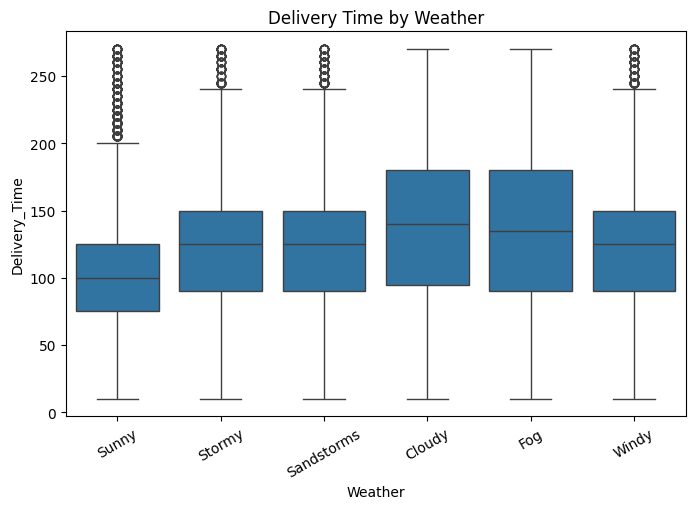

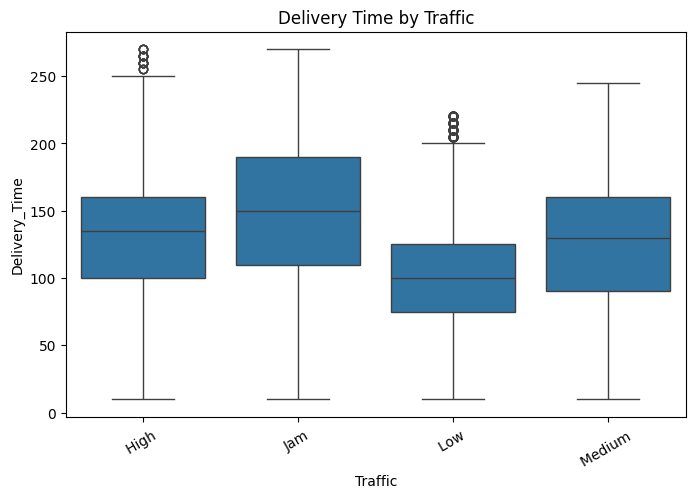

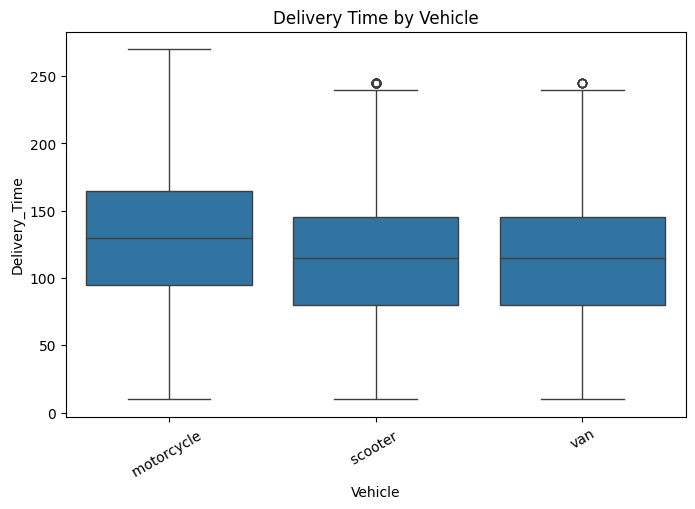

In [154]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x="Weather", y="Delivery_Time", data=df)
plt.title("Delivery Time by Weather")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="Traffic", y="Delivery_Time", data=df)
plt.title("Delivery Time by Traffic")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="Vehicle", y="Delivery_Time", data=df)
plt.title("Delivery Time by Vehicle")
plt.xticks(rotation=30)
plt.show()


# 5.ML-model (Regression)

In [162]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import numpy as np


features = [
    "Distance_km", "Weather", "Traffic", "Category",
    "Vehicle", "Agent_Rating", "Agent_Age",
    "Prep_Time_Min", "Hour", "DayOfWeek"
]
target = "Delivery_Time"

X = df[features]
y = df[target]


In [163]:
num_features = ["Distance_km", "Agent_Rating", "Agent_Age", "Prep_Time_Min", "Hour"]
cat_features = ["Weather", "Traffic", "Category", "Vehicle", "DayOfWeek"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

In [164]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [165]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
}

results = {}

In [169]:
results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

results_df = pd.DataFrame(results).T.round(3)
print(results_df)


                      MAE    RMSE     R2
Linear Regression  26.748  33.931  0.576
Random Forest      17.632  22.906  0.807
Gradient Boosting  18.982  24.274  0.783


                Feature  Importance
20     Category_Grocery    0.237828
1          Agent_Rating    0.169073
0           Distance_km    0.122168
13         Traffic_Low     0.097732
2             Agent_Age    0.092176
9         Weather_Sunny    0.055249
5        Weather_Cloudy    0.041567
6           Weather_Fog    0.040598
31  Vehicle_motorcycle     0.023846
4                  Hour    0.011723
14      Traffic_Medium     0.011009
12         Traffic_Jam     0.010184
3         Prep_Time_Min    0.008748
34     DayOfWeek_Friday    0.003559
8        Weather_Stormy    0.003485


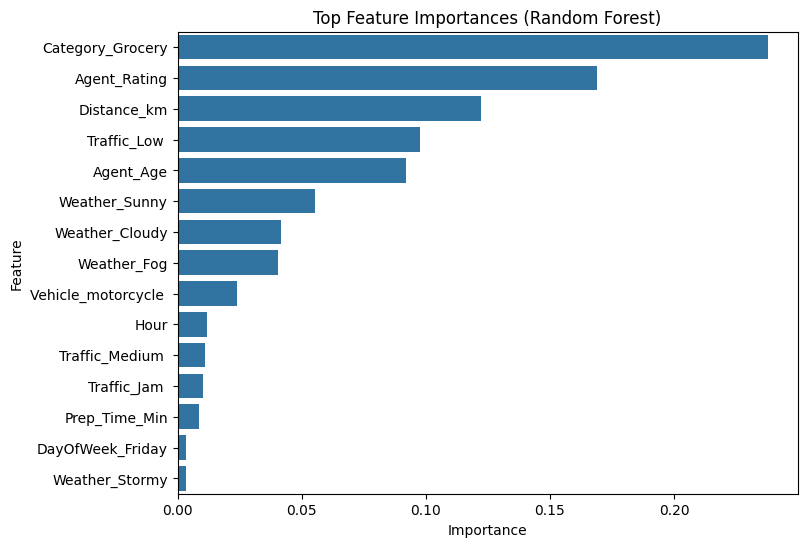

In [170]:
best_pipe = Pipeline(steps=[("preprocessor", preprocessor),
                            ("model", RandomForestRegressor(n_estimators=200, random_state=42))])
best_pipe.fit(X_train, y_train)

ohe = best_pipe.named_steps["preprocessor"].named_transformers_["cat"]
ohe_features = ohe.get_feature_names_out(cat_features)

all_features = num_features + list(ohe_features)

importances = best_pipe.named_steps["model"].feature_importances_
feat_imp = pd.DataFrame({"Feature": all_features, "Importance": importances})
feat_imp = feat_imp.sort_values("Importance", ascending=False)

print(feat_imp.head(15))

plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp.head(15))
plt.title("Top Feature Importances (Random Forest)")
plt.show()


## 🔎 Feature Importance (Random Forest)

The Random Forest model highlights the most important features affecting delivery time:

1. **Category_Grocery** – orders from the Grocery category dominate the feature importance.  
   → Certain product categories strongly impact delivery time (possibly due to demand peaks or handling process).  

2. **Agent_Rating** – higher-rated agents deliver faster.  
   → Couriers with better ratings may be more efficient and experienced.  

3. **Distance_km** – as expected, longer distances increase delivery time.  

4. **Traffic (Low/Medium/Jam)** – traffic intensity is a major factor.  
   → Deliveries during low traffic are consistently faster.  

5. **Agent_Age** – courier age plays a role, though smaller than rating and distance.  

6. **Weather (Sunny, Cloudy, Fog)** – poor weather conditions correlate with longer deliveries.  

7. **Other factors (Hour, DayOfWeek, Prep_Time_Min)** – have a smaller but noticeable influence.

📌 **Conclusion:**  
Delivery time is most strongly influenced by **category of the product, courier rating, and delivery distance**.  
External conditions (traffic, weather) also play a significant role.  
Preparation time and time-of-day effects exist, but their importance is relatively low in this dataset.


# 6. ML model (Classification)



Logistic Regression:

              precision    recall  f1-score   support

        Fast       0.73      0.87      0.79      4248
      Medium       0.45      0.22      0.30      1952
        Slow       0.72      0.78      0.75      2530

    accuracy                           0.70      8730
   macro avg       0.64      0.62      0.61      8730
weighted avg       0.67      0.70      0.67      8730



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


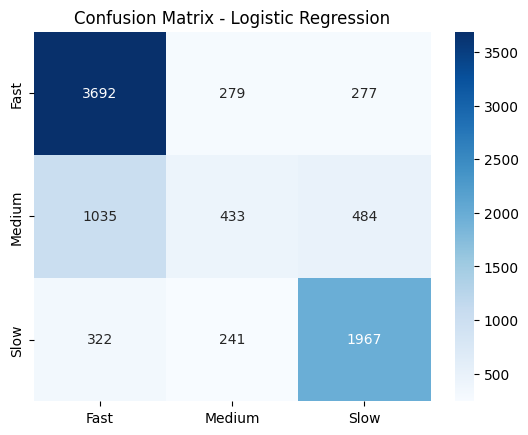


Random Forest:

              precision    recall  f1-score   support

        Fast       0.80      0.90      0.85      4248
      Medium       0.54      0.45      0.49      1952
        Slow       0.90      0.82      0.86      2530

    accuracy                           0.78      8730
   macro avg       0.75      0.72      0.73      8730
weighted avg       0.77      0.78      0.77      8730



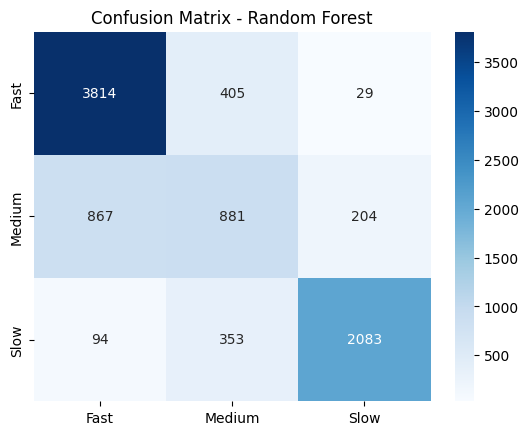

,Accuracy,F1
Logistic Regression,0.698,0.67
Random Forest,0.776,0.77


In [176]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def label_delivery_time(x):
    if x <= 120:
        return "Fast"
    elif x <= 150:
        return "Medium"
    else:
        return "Slow"

df["Delivery_Class"] = df["Delivery_Time"].apply(label_delivery_time)

X = df[features]  
y = df["Delivery_Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results_clf = {}

for name, clf in classifiers.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    results_clf[name] = {"Accuracy": acc, "F1": f1}
    
    print(f"\n{name}:\n")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred, labels=["Fast", "Medium", "Slow"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fast","Medium","Slow"], yticklabels=["Fast","Medium","Slow"])
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

pd.DataFrame(results_clf).T.round(3)


## Classification Results

### Logistic Regression
- Accuracy ~70%  
- Strong in detecting **Fast** deliveries (recall 0.87).  
- Weak in distinguishing **Medium** deliveries (recall only 0.22).  
- Linear baseline, limited power for complex patterns.  

### Random Forest
- Accuracy ~78%  
- Strong detection of **Fast** (recall 0.90) and **Slow** (recall 0.82).  
- **Medium** class remains challenging (recall 0.45).  
- Nonlinear model better captures real-world complexity.  

 **Conclusion:**  
Random Forest clearly outperforms Logistic Regression.  
The main challenge remains the **Medium** class, which overlaps with both Fast and Slow.  
For business use, Random Forest is recommended as the primary classifier.


# 7. Business Insights

Top 3 Fastest Areas:
 Area
Other             104.499120
Urban             109.442628
Metropolitian     129.706962
Name: Delivery_Time, dtype: float64

Top 3 Slowest Areas:
 Area
Urban             109.442628
Metropolitian     129.706962
Semi-Urban        238.552632
Name: Delivery_Time, dtype: float64

Top 3 Fastest Categories:
 Category
Grocery      26.540923
Toys        129.368915
Clothing    130.486476
Name: Delivery_Time, dtype: float64

Top 3 Slowest Categories:
 Category
Sports       132.316488
Kitchen      132.345332
Cosmetics    132.900749
Name: Delivery_Time, dtype: float64


/var/folders/kx/sc3d8b2x5b5gtm156t69kthr0000gn/T/ipykernel_5811/3878426372.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=area_stats.index, y=area_stats.values, palette="coolwarm")


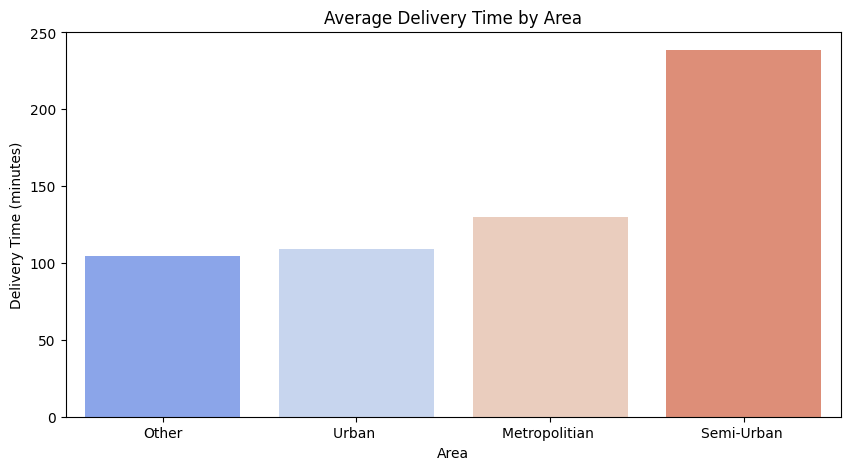

/var/folders/kx/sc3d8b2x5b5gtm156t69kthr0000gn/T/ipykernel_5811/3878426372.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_stats.index, y=category_stats.values, palette="viridis")


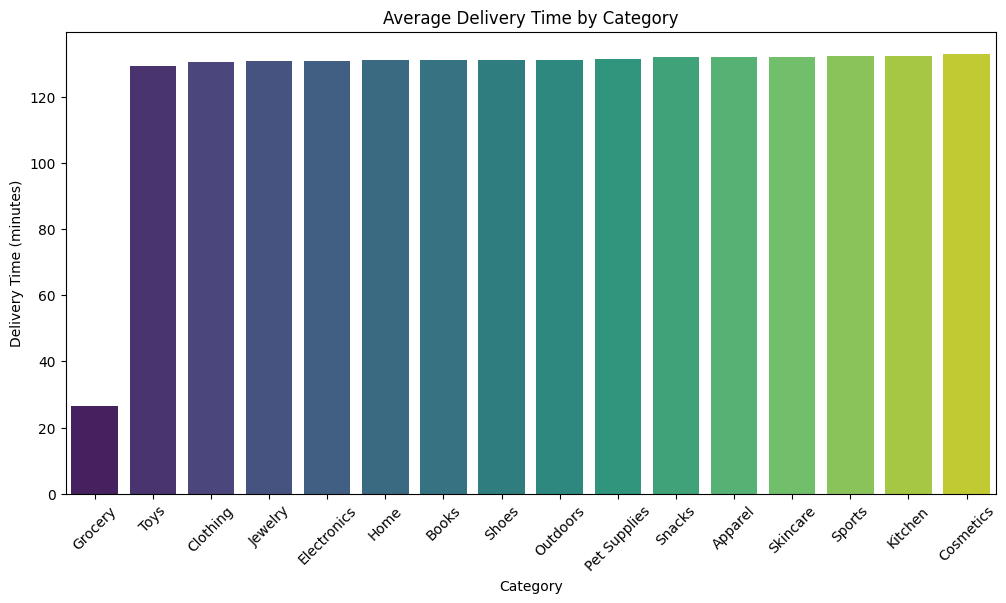

In [178]:
area_stats = df.groupby("Area")["Delivery_Time"].mean().sort_values()

print("Top 3 Fastest Areas:\n", area_stats.head(3))
print("\nTop 3 Slowest Areas:\n", area_stats.tail(3))

category_stats = df.groupby("Category")["Delivery_Time"].mean().sort_values()

print("\nTop 3 Fastest Categories:\n", category_stats.head(3))
print("\nTop 3 Slowest Categories:\n", category_stats.tail(3))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(x=area_stats.index, y=area_stats.values, palette="coolwarm")
plt.title("Average Delivery Time by Area")
plt.ylabel("Delivery Time (minutes)")
plt.show()

plt.figure(figsize=(12,6))
sns.barplot(x=category_stats.index, y=category_stats.values, palette="viridis")
plt.title("Average Delivery Time by Category")
plt.ylabel("Delivery Time (minutes)")
plt.xticks(rotation=45)
plt.show()


## 💡 Business Insights

### Areas
- **Fastest:**
  1. Other – ~104 min  
  2. Urban – ~109 min  
  3. Metropolitan – ~130 min  

- **Slowest:**
  1. Semi-Urban – ~239 min  
  2. Metropolitan – ~130 min  
  3. Urban – ~109 min  

**Insight:**  
Deliveries in **Semi-Urban areas** are by far the slowest (almost double the time of urban areas).  
This shows a clear logistics bottleneck outside major cities.  

---

### Categories
- **Fastest:**
  1. Grocery – ~27 min (! anomaly, extremely fast compared to others)  
  2. Toys – ~129 min  
  3. Clothing – ~130 min  

- **Slowest:**
  1. Sports – ~132 min  
  2. Kitchen – ~132 min  
  3. Cosmetics – ~133 min  

**Insight:**  
- **Grocery stands out**: its average delivery time (~27 min) is far lower than any other category — possibly a data anomaly or special fast-track handling.  
- Most categories cluster around ~130 min, but **Sports, Kitchen, Cosmetics** are the slowest.  
- This may indicate longer preparation or stock/handling issues in these categories.  

---

📌 **Overall Conclusion:**  
- **Semi-Urban logistics** need major optimization (more agents, better routing).  
- **Product categories** differ less dramatically, but focus should be on **Sports, Kitchen, Cosmetics** to reduce delays.  
- **Grocery deliveries** are suspiciously fast — worth double-checking data or investigating whether these deliveries are prioritized differently.


# 📦 Amazon Delivery Time Analysis – Final Summary

### 🔎 Exploratory Data Analysis
- The average delivery time is ~125 minutes.  
- Key influencing factors: **weather, traffic, area type, and vehicle type**.  
- Courier-related factors: **age has little impact**, but **higher ratings are correlated with faster deliveries**.  

### 🌍 Geoanalysis
- The average delivery distance is less than 20 km.  
- Correlation: delivery time increases with distance, but not perfectly linearly – **traffic and weather strongly affect delays**.  

### ⚙️ Feature Engineering
- New features were created: **Day of Week, Hour of Order, Preparation Time, Courier Age Group**.  
- These features improved the models by capturing temporal patterns.  

### 🤖 Machine Learning – Regression
- **Linear Regression**: MAE ~27 min, R² = 0.58 (weak).  
- **Random Forest Regressor**: MAE ~18 min, R² = 0.81 → best model.  
- **Gradient Boosting**: MAE ~19 min, R² = 0.78.  
- 📌 **Conclusion:** Random Forest performs best for predicting continuous delivery time.  

### 🤖 Machine Learning – Classification
- Classes: Fast (≤120 min), Medium (121–150 min), Slow (>150 min).  
- **Logistic Regression**: Accuracy ~70%, struggled with the *Medium* class.  
- **Random Forest Classifier**: Accuracy ~78%, strong in distinguishing *Fast* and *Slow*.  
- 📌 **Conclusion:** Random Forest outperforms Logistic Regression and is the recommended classifier.  

### 💡 Business Insights
- **Slowest Areas:** Semi-Urban (~239 min), Metropolitan (~130 min).  
- **Fastest Areas:** Other (~104 min), Urban (~109 min).  
- **Slowest Categories:** Sports, Kitchen, Cosmetics (~132–133 min).  
- **Fastest Categories:** Grocery (~27 min), Toys, Clothing (~129–130 min).  

📌 **Business Recommendations:**
1. Improve logistics in **Semi-Urban areas** (expand agents, optimize routing).  
2. Optimize processes for **Sports, Kitchen, and Cosmetics** categories.  
3. Investigate **Grocery** deliveries – extremely fast (~27 min) compared to others → possible priority handling or data anomaly.  
4. Leverage **courier rating** as a strong predictor – retain and incentivize top-performing agents.  

---
